In [1]:
import numpy as np
import xarray as xr
import os
import glob
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.ticker as mticker
import pandas as pd
from scipy.signal import detrend
from scipy import stats
import scipy
from minisom import MiniSom
from scipy import signal
from sklearn.preprocessing import StandardScaler
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

from functions import crop_dom
os.environ["ESMFMKFILE"] = "/users_home/cmcc/ls21622/.conda/envs/DEVELOP/lib/esmf.mk"
import xesmf as xe
from functions import regrid as regrid_func  # renamed to avoid clashing with local `regrid` below
from functions import shift_lon
from functions import detect_hw_grid_numba
from functions import extract_domain_events
from functions import compute_metrics
from functions import process_file_models
from functions import process_file_era5
import pymannkendall as mk
from joblib import Parallel, delayed


In [ ]:
"""
09_soil_moisture_coupling_diagnostic.py

Diagnostic for Reviewer 2, Sec 3.4(1) ("Attribution Uncertainty in
Blocking Regime Frequency Changes").

The Reviewer's alternative explanation has two distinct parts, and this
script tests them separately:

  (A) STATIC COUPLING CONTRAST -- is soil moisture-temperature coupling
      stronger on the HW days of regime 11 than on all MJJAS days
      assigned to regime 11?

  (B) TREND CONFOUND (the actual claim) -- are regime-11 days occurring
      under progressively DRIER conditions over the study period, such
      that "identical circulation regimes produce stronger heatwaves"
      without any change in the circulation-regime relationship itself?

Regime 11 is the target because it is the one regime showing both a
statistically significant increasing ERA5 trend (Section 3.2.5) and
HW-promoting status (Section 3.2.3) -- i.e. the regime whose
"efficiency increase" claim (lines 767-770) this comment questions.

Coupling is quantified via the Terrestrial Coupling Index (TCI; Guo
et al. 2006; Dirmeyer 2011), TCI = std(response) * Corr(SM, response),
here applied with temperature as the response variable (an adaptation
of Dirmeyer's flux-based original, in the same spirit as Seneviratne
et al. 2006's adaptation of Koster et al.'s 2004 precipitation-based
metric). A plain Pearson correlation is also reported for reference.

--------------------------------------------------------------------
METHODOLOGICAL NOTES (differences from the first draft of this script)
--------------------------------------------------------------------
1. ANOMALIES, NOT RAW VALUES. Across MJJAS the domain-mean Tmax rises
   ~10 K while soil moisture dries down, so a correlation of raw daily
   values is dominated by the seasonal cycle and returns a strongly
   negative r with zero land-atmosphere feedback. Worse, it biases the
   headline contrast in a known direction: regime-11 HW days cluster in
   Jul-Aug, a narrower seasonal window carrying less seasonal-cycle
   variance, so they would show a *weaker* raw correlation for purely
   calendrical reasons. Both fields are therefore converted to
   anomalies from a smoothed day-of-year climatology, per grid point,
   before any spatial averaging. A linearly detrended variant is also
   reported, so that (A) measures day-to-day covariability and cannot
   be inflated by the co-trending that (B) tests explicitly.

2. MASKING: BOTH GROUPS GET A WHOLE-DOMAIN VERSION AND A MASKED
   VERSION, COMPUTED SYMMETRICALLY. An earlier draft of this script
   assumed the HW footprint mask (sub_hw) could not be applied to the
   all-days baseline, since sub_hw was assumed to be 0 everywhere on
   days that are not official HW days. This assumption was WRONG:
   sub_hw is a per-pixel, per-day exceedance field (tmax > p90 at that
   grid cell, that day), computed on every summer day, not only on
   days meeting the domain-wide 30% threshold that defines an official
   "HW day". The mask is therefore valid and meaningful on every day,
   and is applied symmetrically to both groups (see diagnostic A2
   below), in addition to the whole-domain comparison (A), which is
   retained since it answers a related but distinct question (the
   day-to-day covariability of domain-mean SM and Tmax, rather than
   the covariability specifically within each day's locally
   hot-exceeding footprint).

3. THE DIFFERENCE IS TESTED, not read off an ordering. Fisher z on the
   two correlations (with an autocorrelation-adjusted effective sample
   size) and a moving-block bootstrap on the TCI difference.

4. THE TREND HAS A CONTROL. A drying trend on regime-11 days is only
   evidence for the Reviewer's confound if it exceeds the background
   drying trend over all MJJAS days. Both are computed, plus their
   difference. Trends use Theil-Sen slopes with a Mann-Kendall test
   whose variance is corrected for serial correlation (Hamed & Rao
   1998); ordinary least squares on yearly means gives optimistic
   p-values here.

5. THE SOIL MOISTURE PERIOD IS DISCOVERED, NOT ASSUMED. Actual file
   coverage is reported and used in every label, rather than assumed
   to match the full study period.

6. Latitude-weighted spatial means; loud failure instead of a silent
   fallback variable; explicit grid-consistency check; duplicate time
   labels dropped.

7. TWO SOIL LAYERS MERGED, NOT TREATED SEPARATELY. ERA5 layer 1
   (swvl1, 0-7 cm) and layer 2 (swvl2, 7-28 cm) are now both available
   for the full study period and are combined into a single 0-28 cm
   volumetric soil moisture field via a depth-weighted average,
   SM = (7*swvl1 + 21*swvl2) / 28, rather than using layer 2 alone.
   This is the standard way to combine ERA5 layers of different
   thickness into one physically meaningful profile-average moisture
   value (a simple unweighted average of the two layers would
   implicitly treat a 7 cm layer as equally representative of the
   profile as a 21 cm layer, which is not correct).

Requires: 00_setup_and_functions.py (import * or run first)
"""

import os
import warnings

from importlib import import_module

setup = import_module("00_setup_and_functions")
globals().update(vars(setup))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import linregress, norm, theilslopes

# ================================================================
# Configuration
# ================================================================
TARGET_REGIME = 11  # 1-indexed, matches manuscript regime numbering
node_target = TARGET_REGIME - 1

min_lon, max_lon = -10, 15
min_lat, max_lat = 42, 58

# ERA5 soil moisture layers to merge (see methodological note 7).
SM_VARNAME_L1 = "swvl1"   # 0-7 cm
SM_VARNAME_L2 = "swvl2"   # 7-28 cm
L1_DEPTH_CM = 7.0
L2_DEPTH_CM = 21.0
TOTAL_DEPTH_CM = L1_DEPTH_CM + L2_DEPTH_CM  # 28 cm
SM_LAYER1_DIR = "/data/cmcc/ls21622/ERA5/scripts_download/lev_1"
SM_LAYER2_DIR = "/data/cmcc/ls21622/ERA5/scripts_download/lev_2"

CLIM_SMOOTH_WINDOW = 15   # days, for the day-of-year climatology
MIN_DAYS_PER_YEAR = 3     # skip years with too few regime days for a stable mean
BOOTSTRAP_N = 5000        # moving-block bootstrap replicates
BOOTSTRAP_BLOCK = 5       # days per block
RANDOM_SEED = 20240517

# What to do if SM / Tmax / HW-mask are not on the same grid after
# cropping. "raise" is the default because xarray would otherwise
# inner-join the coordinates silently and leave very few (or zero)
# shared points. Set to "nearest" only if you know the grids are
# compatible and nearest-neighbour sampling is acceptable.
GRID_MISMATCH_ACTION = "raise"   # "raise" | "nearest"

# Set True only when running interactively.
SHOW_FIGURE = False

OUT_PREFIX = f"regime{TARGET_REGIME}_soil_moisture_diagnostic"

rng = np.random.default_rng(RANDOM_SEED)

# Categorical colours (fixed entity -> colour mapping, never cycled)
C_ALLDAYS = "#2a78d6"   # regime-11, all MJJAS days
C_HWDAYS = "#eb6834"    # regime-11, HW days
C_CONTROL = "#1baf7a"   # all MJJAS days, every regime (background control)
C_INK = "#0b0b0b"
C_INK_2 = "#52514e"
C_GRID = "#dcdbd6"


# ================================================================
# Helpers
# ================================================================
def dedup_time(ds):
    """Drop duplicated time labels (overlapping input files) so that
    later .reindex() calls do not raise on a non-unique index."""
    if "time" not in ds.dims:
        return ds
    try:
        return ds.drop_duplicates("time")
    except AttributeError:  # xarray < 2022.03
        _, keep = np.unique(ds.time.values, return_index=True)
        return ds.isel(time=np.sort(keep))


def normalise_time(ds):
    ds = ds.copy()
    ds["time"] = pd.to_datetime(ds.time.astype("datetime64[ns]")).normalize()
    return ds


def standard_names(ds):
    """Rename ERA5's longitude/latitude/valid_time to lon/lat/time, each
    only if actually present (the first draft assumed valid_time existed
    whenever longitude did)."""
    mapping = {}
    for src, dst in (("longitude", "lon"), ("latitude", "lat"), ("valid_time", "time")):
        if src in ds.variables and dst not in ds.variables:
            mapping[src] = dst
    return ds.rename(mapping) if mapping else ds


def grids_match(da_a, da_b, tol=1e-4):
    for dim in ("lat", "lon"):
        a, b = da_a[dim].values, da_b[dim].values
        if a.shape != b.shape or np.max(np.abs(a - b)) > tol:
            return False
    return True


def reconcile_grid(da, reference, name):
    """Return `da` on `reference`'s horizontal grid, or raise."""
    if grids_match(da, reference):
        return da
    msg = (f"'{name}' is not on the reference grid after cropping "
           f"(lat {da.lat.size} vs {reference.lat.size}, "
           f"lon {da.lon.size} vs {reference.lon.size}). xarray would "
           f"silently inner-join these coordinates and could leave almost "
           f"no shared grid points.")
    if GRID_MISMATCH_ACTION == "nearest":
        print(f"[grid] {msg}\n[grid] Regridding '{name}' by nearest neighbour.")
        return da.reindex(lat=reference.lat, lon=reference.lon, method="nearest")
    raise ValueError(msg + " Set GRID_MISMATCH_ACTION='nearest' to sample it "
                           "onto the reference grid, or regrid the inputs "
                           "properly (conservative remapping) beforehand.")


def area_weighted_mean(da):
    """cos(lat)-weighted spatial mean. Weights renormalise over the
    non-NaN points, so this also does the right thing for the
    HW-footprint-masked fields."""
    w = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(w).mean(dim=["lat", "lon"], skipna=True)


def daily_anomalies(da, window=CLIM_SMOOTH_WINDOW):
    """Per-grid-point anomalies from a smoothed day-of-year climatology.

    The climatology is built from the full available MJJAS record. Leap
    years shift the day-of-year index by one after February; with a
    `window`-day running mean that offset is negligible here.
    """
    clim = da.groupby("time.dayofyear").mean("time")
    clim = clim.rolling(dayofyear=window, center=True, min_periods=1).mean()
    anom = da.groupby("time.dayofyear") - clim
    return anom.drop_vars("dayofyear", errors="ignore")


def detrend_series(s):
    """Remove the least-squares linear trend in time from a daily series."""
    if len(s) < 3:
        return s
    x = s.index.year.values + (s.index.dayofyear.values - 1) / 366.0
    fit = linregress(x, s.values)
    return pd.Series(s.values - (fit.slope * x + fit.intercept), index=s.index)


def lag1_autocorr(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 3:
        return 0.0
    x = x - x.mean()
    denom = np.sum(x * x)
    if denom == 0:
        return 0.0
    return float(np.sum(x[:-1] * x[1:]) / denom)


def effective_n(x, y):
    """Effective sample size for a correlation between two serially
    correlated series (Bretherton et al. 1999)."""
    n = len(x)
    r1 = lag1_autocorr(x) * lag1_autocorr(y)
    if r1 <= 0:
        return float(n)
    return float(np.clip(n * (1 - r1) / (1 + r1), 4, n))


def fisher_z_difference(r1, n1, r2, n2):
    """Two-sided test that two independent correlations differ."""
    if min(n1, n2) <= 3:
        return np.nan, np.nan
    z1, z2 = np.arctanh(np.clip(r1, -0.999999, 0.999999)), np.arctanh(np.clip(r2, -0.999999, 0.999999))
    se = np.sqrt(1.0 / (n1 - 3) + 1.0 / (n2 - 3))
    z = (z1 - z2) / se
    return float(z), float(2 * (1 - norm.cdf(abs(z))))


def tci(sm, response):
    """Terrestrial Coupling Index with temperature as the response."""
    r = np.corrcoef(sm, response)[0, 1]
    return float(np.std(response, ddof=1) * r), float(r)


def moving_block_bootstrap_tci(sm, response, n_boot=BOOTSTRAP_N, block=BOOTSTRAP_BLOCK):
    """Bootstrap distribution of TCI.

    Blocks are taken over the subset's own ordering. Because a regime
    subset is a set of non-contiguous calendar days, a 'block' groups
    days that are usually but not always consecutive; this is an
    approximation that keeps most of the within-spell dependence.
    """
    sm = np.asarray(sm, dtype=float)
    response = np.asarray(response, dtype=float)
    n = len(sm)
    if n < 2 * block:
        return np.full(n_boot, np.nan)
    n_blocks = int(np.ceil(n / block))
    starts_max = n - block
    out = np.empty(n_boot)
    for i in range(n_boot):
        starts = rng.integers(0, starts_max + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        out[i] = tci(sm[idx], response[idx])[0]
    return out


def mann_kendall(values, autocorr_correction=True):
    """Mann-Kendall trend test with the Hamed & Rao (1998) variance
    correction for serial correlation, plus a Theil-Sen slope.

    `values` must be evenly spaced in time (one value per year here).
    Returns (theil_sen_slope, p_value, correction_factor).
    """
    x = np.asarray(values, dtype=float)
    n = len(x)
    if n < 4:
        return np.nan, np.nan, np.nan

    t = np.arange(n, dtype=float)
    s = sum(np.sum(np.sign(x[k + 1:] - x[k])) for k in range(n - 1))

    _, counts = np.unique(x, return_counts=True)
    ties = counts[counts > 1]
    var_s = (n * (n - 1) * (2 * n + 5) - np.sum(ties * (ties - 1) * (2 * ties + 5))) / 18.0

    correction = 1.0
    if autocorr_correction and n >= 10:
        ts_slope = theilslopes(x, t)[0]
        ranks = stats.rankdata(x - ts_slope * t)
        rk = ranks - ranks.mean()
        denom = np.sum(rk ** 2)
        if denom > 0:
            acc = 0.0
            for lag in range(1, n - 2):
                r = np.sum(rk[:n - lag] * rk[lag:]) / denom
                m = n - lag
                lo = (-1 - 1.645 * np.sqrt(m - 1)) / m
                hi = (-1 + 1.645 * np.sqrt(m - 1)) / m
                if r <= lo or r >= hi:
                    acc += m * (m - 1) * (m - 2) * r
            correction = 1 + (2.0 / (n * (n - 1) * (n - 2))) * acc
            correction = float(max(correction, 0.05))  # guard pathological cases
        var_s *= correction

    if var_s <= 0:
        return np.nan, np.nan, correction
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0.0
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(theilslopes(x, t)[0]), float(p), float(correction)


def yearly_mean_with_threshold(series, min_days=MIN_DAYS_PER_YEAR):
    """Yearly means, dropping years with too few days for a stable mean."""
    years = series.index.year
    counts = series.groupby(years).size()
    means = series.groupby(years).mean()
    return means.loc[counts[counts >= min_days].index]


def stars(p):
    if not np.isfinite(p):
        return "n/a"
    return "significant (p<0.05)" if p < 0.05 else "not significant"


# ================================================================
# Load ERA5 soil moisture, BOTH layers, and MERGE them into a single
# depth-weighted 0-28 cm volumetric soil moisture field (methodological
# note 7). A given (year, month) is only used if BOTH layers' files
# exist for it, so the two layers are guaranteed to cover the same
# days before combining.
# ================================================================
requested_years = list(range(ystart, yend + 1))

paired_files = []
for yr in requested_years:
    for mo in [5, 6, 7, 8, 9]:
        f1 = f"{SM_LAYER1_DIR}/ERA5_SM_daily_{yr}_{mo}.nc"
        f2 = f"{SM_LAYER2_DIR}/ERA5_SM_daily_{yr}_{mo}.nc"
        if os.path.exists(f1) and os.path.exists(f2):
            paired_files.append((yr, f1, f2))

if not paired_files:
    raise FileNotFoundError(
        f"No matched layer-1/layer-2 soil-moisture file pairs found for "
        f"{ystart}-{yend}, months 5-9, under {SM_LAYER1_DIR} and {SM_LAYER2_DIR}.")

sm_years_present = sorted({p[0] for p in paired_files})
SM_YSTART, SM_YEND = min(sm_years_present), max(sm_years_present)
SM_PERIOD = f"{SM_YSTART}-{SM_YEND}"

l1_files = [p[1] for p in paired_files]
l2_files = [p[2] for p in paired_files]

print(f"Loading {len(l1_files)} matched layer-1/layer-2 soil moisture file pairs "
      f"({SM_PERIOD}, months 5-9)")
if (SM_YSTART, SM_YEND) != (ystart, yend):
    warnings.warn(
        f"\n*** Soil-moisture record (both layers matched) covers {SM_PERIOD}, but "
        f"the analysis period is {ystart}-{yend}. Every soil-moisture result below "
        f"is for {SM_PERIOD} ONLY. Extend the input files before quoting these "
        f"numbers in the response. ***\n", RuntimeWarning)

ds_sm_l1 = xr.open_mfdataset(l1_files, combine="by_coords")
ds_sm_l1 = standard_names(ds_sm_l1)
ds_sm_l2 = xr.open_mfdataset(l2_files, combine="by_coords")
ds_sm_l2 = standard_names(ds_sm_l2)

if SM_VARNAME_L1 not in ds_sm_l1.data_vars:
    raise KeyError(
        f"'{SM_VARNAME_L1}' not found in the layer-1 soil-moisture files. Available: "
        f"{list(ds_sm_l1.data_vars)}.")
if SM_VARNAME_L2 not in ds_sm_l2.data_vars:
    raise KeyError(
        f"'{SM_VARNAME_L2}' not found in the layer-2 soil-moisture files. Available: "
        f"{list(ds_sm_l2.data_vars)}.")

ds_sm_l1 = ds_sm_l1.sortby("lat")
ds_sm_l1 = crop_dom(ds_sm_l1, min_lon, max_lon, min_lat, max_lat, lon_name="lon", lat_name="lat")
ds_sm_l1 = ds_sm_l1.sel(time=ds_sm_l1.time.dt.month.isin([5, 6, 7, 8, 9]))
ds_sm_l1 = normalise_time(dedup_time(ds_sm_l1))

ds_sm_l2 = ds_sm_l2.sortby("lat")
ds_sm_l2 = crop_dom(ds_sm_l2, min_lon, max_lon, min_lat, max_lat, lon_name="lon", lat_name="lat")
ds_sm_l2 = ds_sm_l2.sel(time=ds_sm_l2.time.dt.month.isin([5, 6, 7, 8, 9]))
ds_sm_l2 = normalise_time(dedup_time(ds_sm_l2))

# The two layers should already share the same days (matched by file
# pair above); intersect defensively in case either file had missing
# days internally.
common_sm_times = ds_sm_l1.time.to_index().intersection(ds_sm_l2.time.to_index())
ds_sm_l1 = ds_sm_l1.sel(time=common_sm_times)
ds_sm_l2 = ds_sm_l2.sel(time=common_sm_times)

field_l1 = ds_sm_l1[SM_VARNAME_L1]
field_l2 = ds_sm_l2[SM_VARNAME_L2]
field_l2 = reconcile_grid(field_l2, field_l1, "soil moisture layer 2 (vs. layer 1 grid)")

# Depth-weighted merge -> single 0-28 cm volumetric soil moisture field.
sm_field = (L1_DEPTH_CM * field_l1 + L2_DEPTH_CM * field_l2) / TOTAL_DEPTH_CM
sm_field = sm_field.rename("sm_0_28cm")
print(f"Merged soil moisture: SM = ({L1_DEPTH_CM:.0f}*swvl1 + {L2_DEPTH_CM:.0f}*swvl2) "
      f"/ {TOTAL_DEPTH_CM:.0f}  (depth-weighted 0-{TOTAL_DEPTH_CM:.0f} cm volumetric mean)")

# ================================================================
# Load ERA5 tmax
# ================================================================
ds_tmax = xr.open_dataset(
    "/data/cmcc/ls21622/ERA5/tmax/postprocessed/ERA5_tmax_day_1975-2024_AMJJASO.nc")
ds_tmax = standard_names(ds_tmax)
ds_tmax = ds_tmax.sortby("lat")
ds_tmax = crop_dom(ds_tmax, min_lon, max_lon, min_lat, max_lat, lon_name="lon", lat_name="lat")
ds_tmax = ds_tmax.sel(time=ds_tmax.time.dt.month.isin([5, 6, 7, 8, 9]))
ds_tmax = ds_tmax.sel(time=ds_tmax.time.dt.year.isin(range(ystart, yend + 1)))
ds_tmax = normalise_time(dedup_time(ds_tmax))
tmax_field = reconcile_grid(ds_tmax.tasmax, sm_field, "ERA5 tmax")

# ================================================================
# HW footprint mask (used only for the labelled sensitivity below)
# ================================================================
ds_hw_mask = xr.open_mfdataset(
    "/work/cmcc/ls21622/HighResMIP/ERA5/ERA5_sub_heatwave_day_*_CWE.nc")
ds_hw_mask = ds_hw_mask.sortby("lat")
ds_hw_mask = crop_dom(ds_hw_mask, min_lon, max_lon, min_lat, max_lat,
                      lon_name="lon", lat_name="lat")
ds_hw_mask = normalise_time(dedup_time(ds_hw_mask))
hw_mask = reconcile_grid(ds_hw_mask.sub_hw, sm_field, "HW footprint mask")

# ================================================================
# Anomalies from a smoothed day-of-year climatology, per grid point,
# BEFORE spatial averaging (see methodological note 1).
# ================================================================
sm_anom_field = daily_anomalies(sm_field)
tmax_anom_field = daily_anomalies(tmax_field)

sm_anom = area_weighted_mean(sm_anom_field).to_series()
tmax_anom = area_weighted_mean(tmax_anom_field).to_series()

# HW-footprint-restricted means -- sensitivity only, NOT comparable to
# the whole-domain baseline (methodological note 2).
sm_anom_hwmask = area_weighted_mean(sm_anom_field.where(hw_mask == 1)).to_series()
tmax_anom_hwmask = area_weighted_mean(tmax_anom_field.where(hw_mask == 1)).to_series()

# Raw (non-anomaly) whole-domain means, kept only to quantify how much
# of the first draft's correlation was the seasonal cycle.
sm_raw = area_weighted_mean(sm_field).to_series()
tmax_raw = area_weighted_mean(tmax_field).to_series()

# ================================================================
# Regime assignment: all-days SOM and HW-days SOM
# ================================================================
ds_som_all = xr.open_mfdataset(
    f'{som_path}/som_ERA5_{VAR}_1975_{yend}_{som_grid_rows}_{som_grid_cols}_'
    f'iterations_{iterations}_learning_rate_{learning_rate}_sigma_{sigma}.nc')
ds_som_all = normalise_time(dedup_time(ds_som_all))
node_all = ds_som_all["bmu_row"].values * som_grid_cols + ds_som_all["bmu_col"].values
time_all = ds_som_all.time.values

ds_som_hw = xr.open_mfdataset(
    f'{som_path}/som_projected_HW_days_ERA5_{VAR}_1975_{yend}_{som_grid_rows}_{som_grid_cols}_'
    f'iterations_{iterations}_learning_rate_{learning_rate}_sigma_{sigma}.nc')
ds_som_hw = normalise_time(dedup_time(ds_som_hw))
node_hw = ds_som_hw["bmu_row"].values * som_grid_cols + ds_som_hw["bmu_col"].values
time_hw = ds_som_hw.time.values

all_days_dates = pd.DatetimeIndex(time_all[node_all == node_target])
hw_days_dates = pd.DatetimeIndex(time_hw[node_hw == node_target])

print(f"Regime {TARGET_REGIME}: {len(all_days_dates)} all-MJJAS days, "
      f"{len(hw_days_dates)} HW days (SOM assignment, {ystart}-{yend})")


def paired_subset(sm_series, t_series, dates, detrend=False):
    """Align an SM and a temperature series on a set of days."""
    sm = sm_series.reindex(dates).dropna()
    tt = t_series.reindex(dates).dropna()
    common = sm.index.intersection(tt.index).sort_values()
    sm, tt = sm.loc[common], tt.loc[common]
    if detrend and len(common) >= 3:
        sm, tt = detrend_series(sm), detrend_series(tt)
    return sm, tt


sm_all, tmax_all = paired_subset(sm_anom, tmax_anom, all_days_dates)
sm_hw, tmax_hw = paired_subset(sm_anom, tmax_anom, hw_days_dates)

sm_all_dt, tmax_all_dt = paired_subset(sm_anom, tmax_anom, all_days_dates, detrend=True)
sm_hw_dt, tmax_hw_dt = paired_subset(sm_anom, tmax_anom, hw_days_dates, detrend=True)

sm_hw_fp, tmax_hw_fp = paired_subset(sm_anom_hwmask, tmax_anom_hwmask, hw_days_dates)
# NEW: the analogous masked series for the all-days group. sub_hw is a
# per-pixel, per-day exceedance field (tmax > p90 at that grid cell,
# that day) computed on EVERY summer day, not only on days meeting the
# domain-wide 30% threshold that defines an official "HW day" -- so,
# unlike an earlier assumption in this script, the mask is not
# structurally restricted to HW days and CAN be applied symmetrically
# to both groups. This gives a properly comparable "locally
# hot-exceeding footprint" contrast, rather than mixing a masked group
# against a whole-domain one.
sm_all_fp, tmax_all_fp = paired_subset(sm_anom_hwmask, tmax_anom_hwmask, all_days_dates)
sm_all_raw, tmax_all_raw = paired_subset(sm_raw, tmax_raw, all_days_dates)
sm_hw_raw, tmax_hw_raw = paired_subset(sm_raw, tmax_raw, hw_days_dates)

if len(sm_all) < 10 or len(sm_hw) < 10:
    raise ValueError(
        f"Too few matched days (all: {len(sm_all)}, HW: {len(sm_hw)}). "
        f"Check that the SOM, soil-moisture and tmax time axes overlap -- "
        f"soil moisture covers {SM_PERIOD} only.")
if len(sm_all_fp) < 10 or len(sm_hw_fp) < 10:
    print(f"[warning] Masked-footprint groups are small (all: {len(sm_all_fp)}, "
          f"HW: {len(sm_hw_fp)}) -- some regime-11 days may have zero grid points "
          f"exceeding the local threshold, and are dropped rather than treated as 0.")

# ================================================================
# (A) STATIC COUPLING CONTRAST
# ================================================================
tci_all, r_all = tci(sm_all.values, tmax_all.values)
tci_hw, r_hw = tci(sm_hw.values, tmax_hw.values)
tci_all_dt, r_all_dt = tci(sm_all_dt.values, tmax_all_dt.values)
tci_hw_dt, r_hw_dt = tci(sm_hw_dt.values, tmax_hw_dt.values)
tci_hw_fp, r_hw_fp = tci(sm_hw_fp.values, tmax_hw_fp.values)
tci_all_fp, r_all_fp = tci(sm_all_fp.values, tmax_all_fp.values)
_, r_all_raw = tci(sm_all_raw.values, tmax_all_raw.values)
_, r_hw_raw = tci(sm_hw_raw.values, tmax_hw_raw.values)

# Significance test for the NOW-SYMMETRIC masked comparison, using the
# same methods as the whole-domain headline test above (Fisher z on
# the correlations; moving-block bootstrap on the TCI difference).
n_eff_all_fp = effective_n(sm_all_fp.values, tmax_all_fp.values)
n_eff_hw_fp = effective_n(sm_hw_fp.values, tmax_hw_fp.values)
z_diff_fp, p_diff_fp = fisher_z_difference(r_all_fp, n_eff_all_fp, r_hw_fp, n_eff_hw_fp)

boot_all_fp = moving_block_bootstrap_tci(sm_all_fp.values, tmax_all_fp.values)
boot_hw_fp = moving_block_bootstrap_tci(sm_hw_fp.values, tmax_hw_fp.values)
ci_all_fp = np.nanpercentile(boot_all_fp, [2.5, 97.5])
ci_hw_fp = np.nanpercentile(boot_hw_fp, [2.5, 97.5])
boot_diff_fp = boot_hw_fp - boot_all_fp
ci_diff_fp = np.nanpercentile(boot_diff_fp, [2.5, 97.5])
p_tci_diff_fp = 2 * min(np.nanmean(boot_diff_fp < 0), np.nanmean(boot_diff_fp > 0))

n_eff_all = effective_n(sm_all.values, tmax_all.values)
n_eff_hw = effective_n(sm_hw.values, tmax_hw.values)
z_diff, p_diff = fisher_z_difference(r_all, n_eff_all, r_hw, n_eff_hw)

boot_all = moving_block_bootstrap_tci(sm_all.values, tmax_all.values)
boot_hw = moving_block_bootstrap_tci(sm_hw.values, tmax_hw.values)
ci_all = np.nanpercentile(boot_all, [2.5, 97.5])
ci_hw = np.nanpercentile(boot_hw, [2.5, 97.5])
boot_diff = boot_hw - boot_all
ci_diff = np.nanpercentile(boot_diff, [2.5, 97.5])
p_tci_diff = 2 * min(np.nanmean(boot_diff < 0), np.nanmean(boot_diff > 0))

print(f"\n{'=' * 68}")
print(f"(A) Soil moisture-temperature coupling, Regime {TARGET_REGIME}")
print(f"    SM = depth-weighted 0-{TOTAL_DEPTH_CM:.0f} cm merge of swvl1+swvl2. "
      f"Anomalies from a {CLIM_SMOOTH_WINDOW}-day-smoothed day-of-year "
      f"climatology; whole-domain, cos(lat)-weighted, on BOTH sides.")
print(f"{'=' * 68}")
print(f"All MJJAS days (n={len(sm_all)}, n_eff={n_eff_all:.0f}): "
      f"r = {r_all:+.3f}   std(T') = {tmax_all.std():.3f} K   "
      f"TCI = {tci_all:+.3f}  [95% CI {ci_all[0]:+.3f}, {ci_all[1]:+.3f}]")
print(f"HW days only   (n={len(sm_hw)}, n_eff={n_eff_hw:.0f}): "
      f"r = {r_hw:+.3f}   std(T') = {tmax_hw.std():.3f} K   "
      f"TCI = {tci_hw:+.3f}  [95% CI {ci_hw[0]:+.3f}, {ci_hw[1]:+.3f}]")
print(f"\nDifference (HW - all days):")
print(f"  correlation: Fisher z = {z_diff:+.2f}, p = {p_diff:.3f} -> {stars(p_diff)}")
print(f"  TCI:         delta = {tci_hw - tci_all:+.3f} "
      f"[95% CI {ci_diff[0]:+.3f}, {ci_diff[1]:+.3f}], "
      f"p = {p_tci_diff:.3f} -> {stars(p_tci_diff)}")

print(f"\nSensitivity / robustness:")
print(f"  linearly detrended:     r_all = {r_all_dt:+.3f}, r_HW = {r_hw_dt:+.3f}, "
      f"TCI_all = {tci_all_dt:+.3f}, TCI_HW = {tci_hw_dt:+.3f}")
print(f"  RAW values (seasonal cycle NOT removed, for reference only):")
print(f"                          r_all = {r_all_raw:+.3f}, r_HW = {r_hw_raw:+.3f}")
print(f"     -> the gap between the raw and anomaly correlations is the "
      f"seasonal-cycle artefact.")

print(f"\n{'=' * 68}")
print(f"(A2) LOCALLY-MASKED coupling contrast (sub_hw==1, both groups)")
print(f"     sub_hw is a per-pixel, per-day exceedance field computed on EVERY")
print(f"     summer day (not only official HW days), so it CAN be applied")
print(f"     symmetrically to both groups -- unlike the whole-domain contrast")
print(f"     above, this compares like with like: the soil moisture-temperature")
print(f"     relationship specifically within each day's locally hot-exceeding")
print(f"     footprint, whether or not that day was part of an official HW event.")
print(f"{'=' * 68}")
print(f"All regime-11 days, masked (n={len(sm_all_fp)}, n_eff={n_eff_all_fp:.0f}): "
      f"r = {r_all_fp:+.3f}   std(T') = {tmax_all_fp.std():.3f} K   "
      f"TCI = {tci_all_fp:+.3f}  [95% CI {ci_all_fp[0]:+.3f}, {ci_all_fp[1]:+.3f}]")
print(f"HW days, masked         (n={len(sm_hw_fp)}, n_eff={n_eff_hw_fp:.0f}): "
      f"r = {r_hw_fp:+.3f}   std(T') = {tmax_hw_fp.std():.3f} K   "
      f"TCI = {tci_hw_fp:+.3f}  [95% CI {ci_hw_fp[0]:+.3f}, {ci_hw_fp[1]:+.3f}]")
print(f"\nDifference (HW - all days), masked:")
print(f"  correlation: Fisher z = {z_diff_fp:+.2f}, p = {p_diff_fp:.3f} -> {stars(p_diff_fp)}")
print(f"  TCI:         delta = {tci_hw_fp - tci_all_fp:+.3f} "
      f"[95% CI {ci_diff_fp[0]:+.3f}, {ci_diff_fp[1]:+.3f}], "
      f"p = {p_tci_diff_fp:.3f} -> {stars(p_tci_diff_fp)}")
print()
if not np.isfinite(p_tci_diff_fp) or p_tci_diff_fp >= 0.05:
    print(f"VERDICT (A2): masked coupling is NOT distinguishable between HW days and")
    print(f"  all regime-{TARGET_REGIME} days -- consistent with (A)'s whole-domain verdict.")
else:
    direction = "MORE NEGATIVE" if tci_hw_fp < tci_all_fp else "LESS negative"
    print(f"VERDICT (A2): masked TCI is significantly {direction} on HW days "
          f"(p = {p_tci_diff_fp:.3f}).")

print()
if not np.isfinite(p_tci_diff) or p_tci_diff >= 0.05:
    print(f"VERDICT (A): coupling on HW days is NOT distinguishable from coupling")
    print(f"  across all regime-{TARGET_REGIME} days (TCI difference "
          f"{tci_hw - tci_all:+.3f}, p = {p_tci_diff:.3f}).")
    print(f"  --> no support for a stronger-feedback state on the HW days of")
    print(f"      this regime; note this is a static contrast and says nothing")
    print(f"      about change over time -- see (B), which is the Reviewer's")
    print(f"      actual claim.")
elif tci_hw < tci_all:
    print(f"VERDICT (A): TCI is significantly MORE NEGATIVE on HW days "
          f"(p = {p_tci_diff:.3f}).")
    print(f"  --> consistent with enhanced land-atmosphere feedback under HW")
    print(f"      conditions within this regime.")
else:
    print(f"VERDICT (A): TCI is significantly LESS negative on HW days "
          f"(p = {p_tci_diff:.3f}).")
    print(f"  --> opposite to the enhanced-feedback alternative.")

# ================================================================
# (B) TREND CONFOUND -- the Reviewer's actual claim, with a control
# ================================================================
sm_regime_yearly = yearly_mean_with_threshold(sm_anom.reindex(all_days_dates).dropna())
sm_control_yearly = sm_anom.groupby(sm_anom.index.year).mean()  # all MJJAS days
sm_control_yearly = sm_control_yearly.loc[sm_control_yearly.index.isin(sm_regime_yearly.index)]

slope_regime, p_regime, corr_regime = mann_kendall(sm_regime_yearly.values)
slope_control, p_control, corr_control = mann_kendall(sm_control_yearly.values)

# Difference series: regime-11 SM anomaly relative to the same year's
# all-MJJAS SM anomaly. A trend here is a regime-SPECIFIC drying signal,
# i.e. what the Reviewer's confound actually requires.
sm_excess_yearly = sm_regime_yearly - sm_control_yearly
slope_excess, p_excess, _ = mann_kendall(sm_excess_yearly.values)

print(f"\n{'=' * 68}")
print(f"(B) Soil moisture TREND on Regime {TARGET_REGIME} days ({SM_PERIOD})")
print(f"{'=' * 68}")
print(f"Years with >= {MIN_DAYS_PER_YEAR} regime-{TARGET_REGIME} days: "
      f"{len(sm_regime_yearly)} of {SM_YEND - SM_YSTART + 1}")
print(f"Theil-Sen slopes on yearly-mean SM anomaly, Mann-Kendall p "
      f"(Hamed-Rao corrected for serial correlation):")
print(f"  regime-{TARGET_REGIME} days: {slope_regime:+.5f} m3 m-3 / yr, "
      f"p = {p_regime:.3f}  -> {stars(p_regime)}")
print(f"  all MJJAS days (control): {slope_control:+.5f} m3 m-3 / yr, "
      f"p = {p_control:.3f}  -> {stars(p_control)}")
print(f"  regime-specific excess:   {slope_excess:+.5f} m3 m-3 / yr, "
      f"p = {p_excess:.3f}  -> {stars(p_excess)}")

print()
regime_dries = slope_regime < 0 and p_regime < 0.05
excess_dries = slope_excess < 0 and p_excess < 0.05
if regime_dries and excess_dries:
    print(f"VERDICT (B): significant drying on regime-{TARGET_REGIME} days that "
          f"EXCEEDS the")
    print(f"  domain-wide background drying.")
    print(f"  --> supports the alternative explanation: this circulation regime is")
    print(f"      occurring under progressively drier conditions, which could")
    print(f"      account for part of the apparent 'efficiency increase'")
    print(f"      independent of the circulation-regime relationship itself.")
elif regime_dries:
    print(f"VERDICT (B): regime-{TARGET_REGIME} days do dry significantly, but the "
          f"trend is not")
    print(f"  distinguishable from the domain-wide background drying "
          f"(excess p = {p_excess:.3f}).")
    print(f"  --> the drying is not specific to this regime; it is the general")
    print(f"      MJJAS background, which affects all regimes alike and so cannot")
    print(f"      explain a regime-{TARGET_REGIME}-specific efficiency increase.")
else:
    print(f"VERDICT (B): no significant drying trend on regime-{TARGET_REGIME} days "
          f"over {SM_PERIOD}")
    print(f"  (Theil-Sen {slope_regime:+.5f} m3 m-3 / yr, p = {p_regime:.3f}).")
    print(f"  --> does not support the land-atmosphere-feedback-trend alternative;")
    print(f"      the efficiency increase is not attributable to a soil-moisture")
    print(f"      drying trend within this regime's occurrences.")

if (SM_YSTART, SM_YEND) != (ystart, yend):
    print(f"\n  CAVEAT: soil moisture covers {SM_PERIOD}, not {ystart}-{yend}. "
          f"This verdict\n  is for the shorter period only.")

# ================================================================
# Machine-readable summary
# ================================================================
summary = pd.DataFrame([
    {"quantity": "r", "subset": "regime all days (whole domain, anom)", "value": r_all,
     "n": len(sm_all), "p": np.nan},
    {"quantity": "r", "subset": "regime HW days (whole domain, anom)", "value": r_hw,
     "n": len(sm_hw), "p": np.nan},
    {"quantity": "r difference (Fisher z)", "subset": "HW - all days", "value": r_hw - r_all,
     "n": np.nan, "p": p_diff},
    {"quantity": "TCI", "subset": "regime all days (whole domain, anom)", "value": tci_all,
     "n": len(sm_all), "p": np.nan},
    {"quantity": "TCI", "subset": "regime HW days (whole domain, anom)", "value": tci_hw,
     "n": len(sm_hw), "p": np.nan},
    {"quantity": "TCI difference (bootstrap)", "subset": "HW - all days",
     "value": tci_hw - tci_all, "n": np.nan, "p": p_tci_diff},
    {"quantity": "r", "subset": "regime all days (sub_hw-masked, anom)",
     "value": r_all_fp, "n": len(sm_all_fp), "p": np.nan},
    {"quantity": "r", "subset": "regime HW days (sub_hw-masked, anom)",
     "value": r_hw_fp, "n": len(sm_hw_fp), "p": np.nan},
    {"quantity": "r difference (Fisher z), masked", "subset": "HW - all days",
     "value": r_hw_fp - r_all_fp, "n": np.nan, "p": p_diff_fp},
    {"quantity": "TCI", "subset": "regime all days (sub_hw-masked, anom)",
     "value": tci_all_fp, "n": len(sm_all_fp), "p": np.nan},
    {"quantity": "TCI", "subset": "regime HW days (sub_hw-masked, anom)",
     "value": tci_hw_fp, "n": len(sm_hw_fp), "p": np.nan},
    {"quantity": "TCI difference (bootstrap), masked", "subset": "HW - all days",
     "value": tci_hw_fp - tci_all_fp, "n": np.nan, "p": p_tci_diff_fp},
    {"quantity": "r", "subset": "regime all days (RAW, seasonal cycle included)",
     "value": r_all_raw, "n": len(sm_all_raw), "p": np.nan},
    {"quantity": "r", "subset": "regime HW days (RAW, seasonal cycle included)",
     "value": r_hw_raw, "n": len(sm_hw_raw), "p": np.nan},
    {"quantity": "SM trend (Theil-Sen, /yr)", "subset": f"regime {TARGET_REGIME} days",
     "value": slope_regime, "n": len(sm_regime_yearly), "p": p_regime},
    {"quantity": "SM trend (Theil-Sen, /yr)", "subset": "all MJJAS days (control)",
     "value": slope_control, "n": len(sm_control_yearly), "p": p_control},
    {"quantity": "SM trend (Theil-Sen, /yr)", "subset": "regime-specific excess",
     "value": slope_excess, "n": len(sm_excess_yearly), "p": p_excess},
])
summary["period"] = SM_PERIOD
summary["sm_definition"] = f"depth-weighted 0-{TOTAL_DEPTH_CM:.0f}cm (swvl1+swvl2 merge)"
summary.to_csv(f"{OUT_PREFIX}_summary.csv", index=False)
print(f"\nWrote {OUT_PREFIX}_summary.csv")

# ================================================================
# Figure
# ================================================================
fig, axs = plt.subplots(1, 4, figsize=(21.5, 5.0))
for ax in axs:
    ax.set_facecolor("#fcfcfb")
    ax.grid(True, color=C_GRID, linewidth=0.8, alpha=0.9, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(C_GRID)
    ax.tick_params(colors=C_INK_2, labelsize=13)

# --- Panel (a): SM' vs Tmax' scatter, one mask on both sides ---
ax = axs[0]
for xs, ys, color, label in (
        (sm_all.values, tmax_all.values, C_ALLDAYS, f"All MJJAS days (n={len(sm_all)})"),
        (sm_hw.values, tmax_hw.values, C_HWDAYS, f"HW days (n={len(sm_hw)})")):
    ax.scatter(xs, ys, s=24, color=color, alpha=0.65, linewidths=0.6,
               edgecolors="#fcfcfb", label=label, zorder=3)
    fit = linregress(xs, ys)
    xl = np.linspace(xs.min(), xs.max(), 20)
    ax.plot(xl, fit.slope * xl + fit.intercept, color=color, linewidth=2, zorder=4)

ax.axhline(0, color=C_GRID, linewidth=1, zorder=1)
ax.axvline(0, color=C_GRID, linewidth=1, zorder=1)
x_abs_max = max(abs(sm_all.min()), abs(sm_all.max()), abs(sm_hw.min()), abs(sm_hw.max()))
y_abs_max = max(abs(tmax_all.min()), abs(tmax_all.max()), abs(tmax_hw.min()), abs(tmax_hw.max()))
ax.set_xlim(-x_abs_max * 1.05, x_abs_max * 1.05)
ax.set_ylim(-y_abs_max * 1.05, y_abs_max * 1.05)
ax.set_xlabel(f"Soil moisture anomaly (0-{TOTAL_DEPTH_CM:.0f}cm merged, m$^3$ m$^{{-3}}$)",
              fontsize=14, color=C_INK_2)
ax.set_ylabel("Tmax anomaly (K)", fontsize=14, color=C_INK_2)
ax.set_title(f"(a) SM'-Tmax' coupling, Regime {TARGET_REGIME}\n"
             f"all days r={r_all:+.2f}   |   HW days r={r_hw:+.2f}   "
             f"(difference {'sig.' if np.isfinite(p_diff) and p_diff < 0.05 else 'n.s.'})",
             fontsize=15, color=C_INK, loc="left")
ax.legend(fontsize=12, frameon=False, labelcolor=C_INK_2)

# --- Panel (b): TCI with bootstrap 95% CI ---
ax = axs[1]
labels = ["All MJJAS days", "HW days"]
vals = [tci_all, tci_hw]
cis = [ci_all, ci_hw]
colors = [C_ALLDAYS, C_HWDAYS]
xpos = np.arange(2)
for i, (v, ci, c) in enumerate(zip(vals, cis, colors)):
    ax.bar(xpos[i], v, width=0.5, color=c, zorder=3,
           edgecolor="#fcfcfb", linewidth=2)
    ax.plot([xpos[i], xpos[i]], ci, color=C_INK_2, linewidth=2, zorder=4)
    below = v < 0
    ax.annotate(f"{v:+.3f}", xy=(xpos[i], ci[0] if below else ci[1]),
                xytext=(0, -10 if below else 10), textcoords="offset points",
                ha="center", va="top" if below else "bottom",
                fontsize=13, color=C_INK, zorder=5)

lo = min(np.min(ci_all), np.min(ci_hw), 0.0)
hi = max(np.max(ci_all), np.max(ci_hw), 0.0)
span = (hi - lo) or 1.0
ax.set_ylim(lo - 0.22 * span, hi + 0.12 * span)
ax.axhline(0, color=C_INK_2, linewidth=1, zorder=2)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=14, color=C_INK_2)
ax.set_xlabel("whiskers: moving-block bootstrap 95% CI",
              fontsize=12, color=C_INK_2)
ax.set_ylabel("TCI  =  std(Tmax')  ×  corr(SM', Tmax')", fontsize=14, color=C_INK_2)
ax.set_title(f"(b) Terrestrial Coupling Index, whole domain\n"
             f"difference {tci_hw - tci_all:+.3f} "
             f"[{ci_diff[0]:+.3f}, {ci_diff[1]:+.3f}] "
             f"({'sig.' if p_tci_diff < 0.05 else 'n.s.'})",
             fontsize=15, color=C_INK, loc="left")

# --- Panel (c): yearly SM anomaly, regime-11 days vs all-days control ---
ax = axs[2]
for series, slope, pval, color, label in (
        (sm_regime_yearly, slope_regime, p_regime, C_ALLDAYS,
         f"Regime {TARGET_REGIME} days"),
        (sm_control_yearly, slope_control, p_control, C_CONTROL,
         "All MJJAS days (control)")):
    yrs = series.index.values.astype(float)
    ax.plot(yrs, series.values, marker="o", markersize=5, linewidth=1.2,
            color=color, alpha=0.85, markeredgecolor="#fcfcfb",
            markeredgewidth=0.6, zorder=3,
            label=f"{label}: {slope:+.5f}/yr, p={pval:.2f}")
    ts = theilslopes(series.values, yrs)
    ax.plot(yrs, ts[1] + ts[0] * yrs, color=color, linewidth=2,
            linestyle="--", zorder=4)

ax.axhline(0, color=C_GRID, linewidth=1, zorder=1)
ax.margins(y=0.18)
ax.set_xlabel("Year", fontsize=14, color=C_INK_2)
ax.set_ylabel(f"Yearly-mean SM anomaly (0-{TOTAL_DEPTH_CM:.0f}cm, m$^3$ m$^{{-3}}$)",
              fontsize=14, color=C_INK_2)
ax.set_title(f"(c) Soil moisture trend, {SM_PERIOD}\n"
             f"regime-specific excess {slope_excess:+.5f}/yr "
             f"({'sig.' if np.isfinite(p_excess) and p_excess < 0.05 else 'n.s.'})",
             fontsize=15, color=C_INK, loc="left")
ax.legend(fontsize=12, frameon=False, labelcolor=C_INK_2, loc="lower left")

# --- Panel (d): TCI with bootstrap 95% CI, sub_hw-MASKED (both groups) ---
'''ax = axs[3]
labels_fp = ["All MJJAS days\n(masked)", "HW days\n(masked)"]
vals_fp = [tci_all_fp, tci_hw_fp]
cis_fp = [ci_all_fp, ci_hw_fp]
colors_fp = [C_ALLDAYS, C_HWDAYS]
xpos_fp = np.arange(2)
for i, (v, ci, c) in enumerate(zip(vals_fp, cis_fp, colors_fp)):
    ax.bar(xpos_fp[i], v, width=0.5, color=c, zorder=3,
           edgecolor="#fcfcfb", linewidth=2)
    ax.plot([xpos_fp[i], xpos_fp[i]], ci, color=C_INK_2, linewidth=2, zorder=4)
    below = v < 0
    ax.annotate(f"{v:+.3f}", xy=(xpos_fp[i], ci[0] if below else ci[1]),
                xytext=(0, -10 if below else 10), textcoords="offset points",
                ha="center", va="top" if below else "bottom",
                fontsize=13, color=C_INK, zorder=5)

lo_fp = min(np.min(ci_all_fp), np.min(ci_hw_fp), 0.0)
hi_fp = max(np.max(ci_all_fp), np.max(ci_hw_fp), 0.0)
span_fp = (hi_fp - lo_fp) or 1.0
ax.set_ylim(lo_fp - 0.22 * span_fp, hi_fp + 0.12 * span_fp)
ax.axhline(0, color=C_INK_2, linewidth=1, zorder=2)
ax.set_xticks(xpos_fp)
ax.set_xticklabels(labels_fp, fontsize=14, color=C_INK_2)
ax.tick_params(axis="y", labelsize=13)
ax.set_xlabel("whiskers: moving-block bootstrap 95% CI",
              fontsize=12, color=C_INK_2)
ax.set_ylabel("TCI  =  std(Tmax')  ×  corr(SM', Tmax')", fontsize=14, color=C_INK_2)
ax.set_title(f"(d) TCI, sub_hw-masked (both groups)\n"
             f"difference {tci_hw_fp - tci_all_fp:+.3f} "
             f"[{ci_diff_fp[0]:+.3f}, {ci_diff_fp[1]:+.3f}] "
             f"({'sig.' if p_tci_diff_fp < 0.05 else 'n.s.'})",
             fontsize=15, color=C_INK, loc="left")'''

plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}.png", dpi=300, bbox_inches="tight",
            facecolor="#fcfcfb")
print(f"Wrote {OUT_PREFIX}.png")
if SHOW_FIGURE:
    plt.show()

Loading 200 matched layer-1/layer-2 soil moisture file pairs (1975-2014, months 5-9)
Merged soil moisture: SM = (7*swvl1 + 21*swvl2) / 28  (depth-weighted 0-28 cm volumetric mean)


In [ ]:
"""
08_cmcc_evap_fraction_diagnostic.py

Preliminary diagnostic for Reviewer 2, Sec 3.3(2): does CMCC's
evaporative-fraction dry bias intensify at high resolution as an
AMPLIFICATION of the same spatial pattern (consistent with a fixed,
untuned CLM4.5 land-surface parameterization; Scoccimarro et al. 2022),
or as a qualitatively different pattern?

No daily soil moisture is available for CMCC (only monthly means, not
usable for a HW-day-specific diagnostic), so this uses evaporative
fraction (EF = hfls / (hfls + hfss)) during HW days instead, which IS
available daily.

Requires: 00_setup_and_functions.py (import * or run first)
"""

from importlib import import_module
setup = import_module("00_setup_and_functions")
globals().update(vars(setup))

CMCC_INDEX = models.index("CMCC-CM2_r1")
mod_lr = models_lr[CMCC_INDEX]
mod_hr = models_hr[CMCC_INDEX]
realization = realizations[CMCC_INDEX]
grid = grids[CMCC_INDEX]

min_lon, max_lon = -10, 15
min_lat, max_lat = 42, 58


def load_ef(hfls_file, hfss_file, hw_mask_file):
    """Load hfls/hfss, restrict to HW days, return mean evaporative
    fraction field over the domain."""

    ds_hfls = xr.open_dataset(hfls_file)
    ds_hfss = xr.open_dataset(hfss_file)
    
    if 'longitude' in ds_hfls: 
        ds_hfls = xr.open_dataset(hfls_file).rename({'longitude':'lon','latitude':'lat','valid_time':'time'}).sortby('lat')
        ds_hfss = xr.open_dataset(hfss_file).rename({'longitude':'lon','latitude':'lat','valid_time':'time'}).sortby('lat')
 

    
    # Normalize the model's own time coordinate to midnight, matching
    # ds_hw_mask below -- without this, .where(sub_hw == 1) silently
    # returns all-NaN if the model's native timestamps carry a
    # non-midnight time-of-day component (e.g. 12:00:00), since the
    # time coordinates then never align.
    ds_hfls["time"] = pd.to_datetime(ds_hfls.time.astype("datetime64[ns]")).normalize()
    ds_hfss["time"] = pd.to_datetime(ds_hfss.time.astype("datetime64[ns]")).normalize()
    if ds_hfls.lon.min() >= 0:
        ds_hfls = shift_lon(ds_hfls)
        ds_hfss = shift_lon(ds_hfss)
    ds_hfls = crop_dom(ds_hfls, min_lon, max_lon, min_lat, max_lat, lon_name='lon', lat_name='lat')
    ds_hfss = crop_dom(ds_hfss, min_lon, max_lon, min_lat, max_lat, lon_name='lon', lat_name='lat')
    ds_hfls = ds_hfls.sel(time=ds_hfls.time.dt.month.isin([5, 6, 7, 8, 9]))
    ds_hfss = ds_hfss.sel(time=ds_hfss.time.dt.month.isin([5, 6, 7, 8, 9]))

    ds_hw_mask = xr.open_mfdataset(hw_mask_file)
    ds_hw_mask["time"] = pd.to_datetime(ds_hw_mask.time.astype("datetime64[ns]")).normalize()
    ds_hw_mask = ds_hw_mask.sel(time=ds_hw_mask.time.dt.month.isin([5, 6, 7, 8, 9]))

    hfls_hw = ds_hfls.hfls.where(ds_hw_mask.sub_hw == 1)
    hfss_hw = ds_hfss.hfss.where(ds_hw_mask.sub_hw == 1)


    denom = hfls_hw + hfss_hw
    ef = (hfls_hw / denom).where(np.abs(denom) > 10)  # W/m² threshold, adjust as appropriate
    
    return ef.reduce(np.nanmean, dim="time")


# --- ERA5 ---
ef_era5 = load_ef(
    "/data/cmcc/ls21622/ERA5/hfls/postprocessed/ERA5_hfls_day_1975-2024_AMJJASO.nc",
    "/data/cmcc/ls21622/ERA5/hfss/postprocessed/ERA5_hfss_day_1975-2024_AMJJASO.nc",
    "/work/cmcc/ls21622/HighResMIP/ERA5/ERA5_sub_heatwave_day_*_CWE.nc",
)

# --- CMCC LR and HR ---
ef_cmcc = {}
for res, mod_name in [("lr", mod_lr), ("hr", mod_hr)]:
    hfls_file = (f"/data/cmcc/am35323/HighResMIP/{mod_name}/{realization}/hfls/1975_2024/"
                 f"hfls_day_{mod_name}_historical_{realization}_{grid}_1975-2024_AMJJASO.nc")
    hfss_file = (f"/data/cmcc/am35323/HighResMIP/{mod_name}/{realization}/hfss/1975_2024/"
                 f"hfss_day_{mod_name}_historical_{realization}_{grid}_1975-2024_AMJJASO.nc")
    hw_mask_file = f"/work/cmcc/ls21622/HighResMIP/{mod_name}/{realization}/hw_metrics/*sub_heatwave_day_*_CWE.nc"
    ef_cmcc[res] = load_ef(hfls_file, hfss_file, hw_mask_file)

# --- Regrid CMCC to ERA5 grid, compute bias ---
ef_lr_regrid = regrid(ef_cmcc["lr"].to_dataset(name="ef"), ef_era5.to_dataset(name="ef"), method).ef
ef_hr_regrid = regrid(ef_cmcc["hr"].to_dataset(name="ef"), ef_era5.to_dataset(name="ef"), method).ef

bias_lr = ef_lr_regrid.values - ef_era5.values
bias_hr = ef_hr_regrid.values - ef_era5.values

valid = np.isfinite(bias_lr) & np.isfinite(bias_hr)
bias_lr_flat = bias_lr[valid]
bias_hr_flat = bias_hr[valid]

# --- Diagnostics ---
spatial_corr = np.corrcoef(bias_lr_flat, bias_hr_flat)[0, 1]
mean_bias_lr = np.nanmean(bias_lr)
mean_bias_hr = np.nanmean(bias_hr)

DRY_THRESHOLD = -0.1
frac_dry_lr = np.mean(bias_lr_flat < DRY_THRESHOLD) * 100
frac_dry_hr = np.mean(bias_hr_flat < DRY_THRESHOLD) * 100

max_dry_lr = np.nanmin(bias_lr)
max_dry_hr = np.nanmin(bias_hr)

print("=== CMCC evaporative fraction bias: LR vs HR spatial pattern ===")
print(f"Spatial correlation (LR bias vs HR bias pattern): r = {spatial_corr:.3f}")
print(f"Domain-mean bias:            LR = {mean_bias_lr:+.3f}   HR = {mean_bias_hr:+.3f}")
print(f"Area with bias < {DRY_THRESHOLD} (%): LR = {frac_dry_lr:.1f}%   HR = {frac_dry_hr:.1f}%")
print(f"Most extreme (driest) bias:  LR = {max_dry_lr:+.3f}   HR = {max_dry_hr:+.3f}")
print()
print("High spatial correlation + larger |mean bias|/area/extreme at HR")
print("  --> supports amplification of the same pattern (fixed, untuned CLM4.5)")
print("Low spatial correlation --> suggests a qualitatively different bias at HR")

# ================================================================
# Physical evaporative fraction maps: LR and HR, native grids (not
# regridded), so any resolution-related spatial detail is preserved
# rather than smoothed away onto ERA5's coarser grid.
# ================================================================
levels_phys = np.linspace(0, 1, 11)
cmap_phys = sns.color_palette("YlOrBr", len(levels_phys) - 1, as_cmap=True)
norm_phys = mcolors.BoundaryNorm(levels_phys, cmap_phys.N, clip=False, extend='neither')

fig, axs = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={"projection": ccrs.PlateCarree()})

for ax, ef_da, title in [(axs[0], ef_cmcc["lr"], "LR"), (axs[1], ef_cmcc["hr"], "HR")]:
    im_phys = ax.pcolormesh(ef_da.lon, ef_da.lat, ef_da, cmap=cmap_phys, norm=norm_phys,
                            shading="auto", transform=ccrs.PlateCarree(), zorder=1)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="black",
                    linewidth=0.6, zorder=2)
    ax.set_title(f"CMCC {title} (native grid)", fontsize=14)

cbar_phys = fig.colorbar(im_phys, ax=axs, orientation="horizontal", fraction=0.06, pad=0.08)
cbar_phys.set_label("Evaporative fraction", fontsize=13)

fig.suptitle("CMCC evaporative fraction during HW days: LR vs. HR (physical values)",
             fontsize=16, y=1.02)
plt.savefig("cmcc_evap_fraction_physical_maps.png", dpi=300, bbox_inches="tight")
plt.show()

# ================================================================
# Bias maps: LR and HR evaporative fraction bias vs. ERA5, side by
# side, same color scale so the two are directly comparable.
# ================================================================
bias_lr_da = ef_lr_regrid - ef_era5
bias_hr_da = ef_hr_regrid - ef_era5

levels = np.linspace(-0.3, 0.3, 13)
cmap = sns.color_palette("RdBu_r", len(levels) - 1, as_cmap=True)
norm = mcolors.BoundaryNorm(levels, cmap.N, clip=False, extend='both')

fig, axs = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={"projection": ccrs.PlateCarree()})

for ax, bias_da, title in [(axs[0], bias_lr_da, "LR"), (axs[1], bias_hr_da, "HR")]:
    im = ax.pcolormesh(bias_da.lon, bias_da.lat, bias_da, cmap=cmap, norm=norm,
                        shading="auto", transform=ccrs.PlateCarree(), zorder=1)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="black",
                    linewidth=0.6, zorder=2)
    ax.set_title(f"CMCC {title} \u2212 ERA5", fontsize=14)

cbar = fig.colorbar(im, ax=axs, orientation="horizontal", fraction=0.06, pad=0.08)
cbar.set_label("Evaporative fraction bias (CMCC \u2212 ERA5)", fontsize=13)

fig.suptitle("CMCC evaporative fraction bias during HW days: LR vs. HR", fontsize=16, y=1.02)
plt.savefig(f"cmcc_evap_fraction_bias_maps.png", dpi=300, bbox_inches="tight")


=== CMCC-CM2-HR4 (own model-trained SOM) vs. ERA5-trained SOM ===
 cmcc_node  best_match_era5_node  match_correlation
         1                    15             0.8607
         2                    11             0.7063
         3                    11             0.7587
         4                     7             0.8524
         5                    12             0.8354
         6                     8             0.7786
         7                     6             0.5622
         8                     6             0.7442
         9                     1             0.8473
        10                     9             0.8646
        11                     5             0.8108
        12                     3             0.7428
        13                     3             0.8443
        14                    13             0.6355
        15                     4             0.8184

Mean best-match correlation across all 15 nodes: 0.7775
Minimum best-match correlation: 0.5622  (CMCC

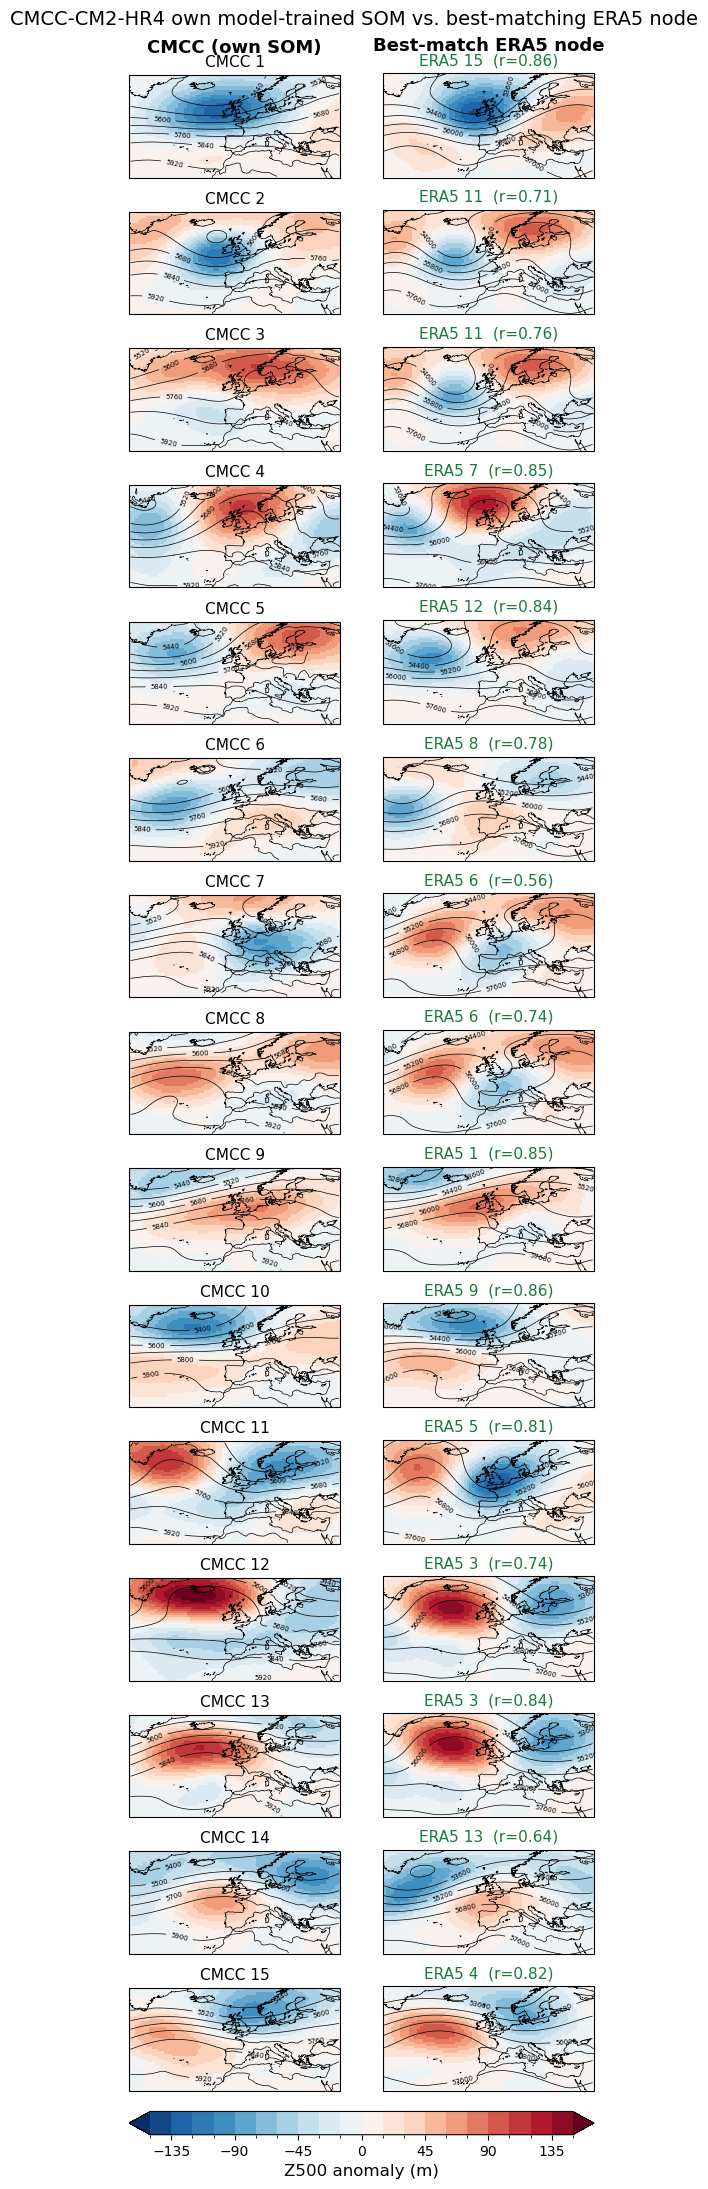

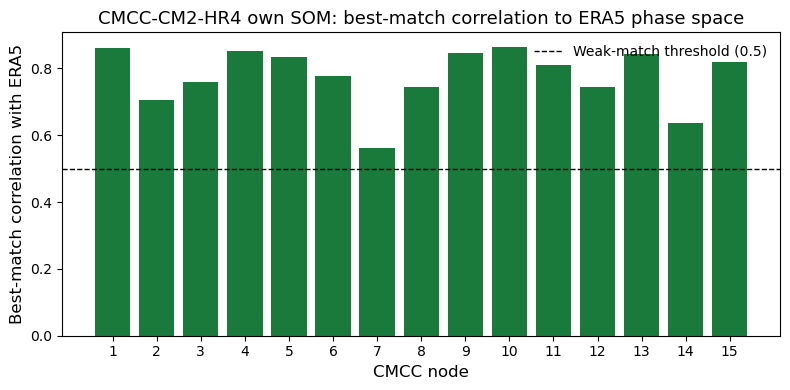

In [10]:
"""
10_cmcc_vs_era5_som_comparison.py

Basic diagnostic for Reviewer 2, Sec 4.3(1)(a) ("Fairness of ERA5 phase
space"): compares CMCC-CM2-HR4's own model-trained master SOM (trained
on CMCC's own Z500 data, not projected onto ERA5's phase space) against
the ERA5-trained SOM used to define the study's phase space throughout.

UPDATE: added a small number of full (non-anomaly) Z500 field contour
lines to both the CMCC and ERA5 panels of the spatial comparison grid,
matching the approach used in 01_era5_som_composites.py (Reviewer 3,
comment 10).

IMPORTANT -- two things need your confirmation before this will run:
1. CMCC_FULL_FIELD_FILE below is a PLACEHOLDER -- I do not have the
   actual path for CMCC-CM2-HR4's full daily Z500 field. Please fill
   this in (analogous to the ERA5 path already used elsewhere).
2. This requires ds_cmcc to contain "bmu_row", "bmu_col", and "time"
   (the day-to-node assignment from CMCC's own training), not just
   "patterns". If ds_cmcc does not have these fields, the CMCC
   composite step below will fail with a clear KeyError -- if so,
   let me know and we can discuss alternatives (e.g., if CMCC's BMU
   assignments are stored in a separate file).

NOTE: this is a basic, single-model, single-direction check (no
downstream re-analysis of HW-promoting efficiency, trends, etc. using
CMCC's own SOM) -- exactly the scope requested.

Requires: 00_setup_and_functions.py (import * or run first)
"""

from importlib import import_module
setup = import_module("00_setup_and_functions")
globals().update(vars(setup))

import pandas as pd

CMCC_SOM_FILE = (
    "/work/cmcc/ls21622/HighResMIP/CMCC-CM2-HR4/r1i1p1f1/som/claude/"
    "CMCC-CM2-HR4_zg_1975_2014_3_5_iterations_10000_learning_rate_0.1_sigma_1.0_init_RND.nc"
)

# PLACEHOLDER -- replace with the actual CMCC-CM2-HR4 full daily Z500
# field path (analogous to the ERA5 path used in
# 01_era5_som_composites.py).
CMCC_FULL_FIELD_FILE = (
    "/work/cmcc/ls21622/HighResMIP/CMCC-CM2-HR4/r1i1p1f1/zg/"
    "zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_1951-2014_AMJJASO.nc"  # <-- CONFIRM/FIX THIS
)

# --- ERA5-trained SOM (defines the study's phase space) ---
ds_era5 = xr.open_mfdataset(
    f'{som_path}/som_ERA5_{VAR}_1975_{yend}_{som_grid_rows}_{som_grid_cols}_'
    f'iterations_{iterations}_learning_rate_{learning_rate}_sigma_{sigma}.nc')
patterns_era5 = ds_era5["patterns"].transpose("som_row", "som_col", "lat", "lon")

# --- CMCC-CM2-HR4's own model-trained SOM ---
ds_cmcc = xr.open_dataset(CMCC_SOM_FILE)
patterns_cmcc = ds_cmcc["patterns"].transpose("som_row", "som_col", "lat", "lon")

n_rows, n_cols, nlat, nlon = patterns_era5.shape
n_nodes = n_rows * n_cols

flat_era5 = patterns_era5.values.reshape(n_nodes, -1)
flat_cmcc = patterns_cmcc.values.reshape(n_nodes, -1)

# Mask out NaN grid points consistently
valid = np.all(np.isfinite(flat_era5), axis=0) & np.all(np.isfinite(flat_cmcc), axis=0)
flat_era5 = flat_era5[:, valid]
flat_cmcc = flat_cmcc[:, valid]


def spatial_corr(a, b):
    a = a - a.mean()
    b = b - b.mean()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


# --- For each CMCC node, find its best-matching ERA5 node ---
node_labels_1idx = [i + 1 for i in range(n_nodes)]
results = []
for k in range(n_nodes):
    corrs = [spatial_corr(flat_cmcc[k], flat_era5[j]) for j in range(n_nodes)]
    best_j = int(np.argmax(corrs))
    results.append({
        "cmcc_node": node_labels_1idx[k],
        "best_match_era5_node": node_labels_1idx[best_j],
        "match_correlation": round(corrs[best_j], 4),
    })

df = pd.DataFrame(results)
print("=== CMCC-CM2-HR4 (own model-trained SOM) vs. ERA5-trained SOM ===")
print(df.to_string(index=False))
print()
print(f"Mean best-match correlation across all {n_nodes} nodes: {df['match_correlation'].mean():.4f}")
print(f"Minimum best-match correlation: {df['match_correlation'].min():.4f}  "
      f"(CMCC node {df.loc[df['match_correlation'].idxmin(), 'cmcc_node']})")
print(f"Maximum best-match correlation: {df['match_correlation'].max():.4f}")

WEAK_MATCH_THRESHOLD = 0.5
weak_matches = df[df["match_correlation"] < WEAK_MATCH_THRESHOLD]
print()
if len(weak_matches) > 0:
    print(f"[note] {len(weak_matches)} CMCC node(s) have a weak best-match correlation "
          f"(< {WEAK_MATCH_THRESHOLD}) against every ERA5 node:")
    print(weak_matches.to_string(index=False))
    print("  --> possible evidence of model-specific circulation states not well")
    print("      represented in the ERA5-defined phase space")
else:
    print(f"All CMCC nodes have a best-match correlation >= {WEAK_MATCH_THRESHOLD} against "
          f"some ERA5 node.")
    print("  --> no evidence in this basic check that CMCC develops circulation states")
    print("      absent from the ERA5-defined phase space")

df.to_csv("cmcc_vs_era5_som_comparison.csv", index=False)
print("\nSaved: cmcc_vs_era5_som_comparison.csv")

# ================================================================
# NEW: Load and preprocess the FULL (non-anomaly) daily Z500 fields
# for both CMCC and ERA5, used for the contour overlay below.
# ================================================================
def to_standard_datetime(time_array):
    """
    Robustly convert a time coordinate to standard (Gregorian)
    datetime64, handling both already-standard arrays (e.g. ERA5) and
    cftime-object arrays with non-standard calendars (e.g. CMCC's
    native 365-day "noleap" calendar, which pd.to_datetime() cannot
    convert directly). Since noleap dates never include Feb 29, every
    noleap date is also a valid Gregorian date -- reconstructing via
    (year, month, day) strings sidesteps the direct type conversion.
    """
    time_array = np.asarray(time_array)
    if len(time_array) == 0:
        return pd.to_datetime(time_array)
    if isinstance(time_array[0], np.datetime64):
        return pd.to_datetime(time_array)
    # cftime object (or similar): reconstruct via (year, month, day)
    return pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" for t in time_array])


def load_full_field(path):
    ds_full = xr.open_dataset(path)
    if "valid_time" in ds_full.coords or "longitude" in ds_full.coords:
        ds_full = ds_full.rename({"valid_time": "time", "longitude": "lon", "latitude": "lat"})
    ds_full = ds_full.sortby("lat")
    if ds_full.lon.min() >= 0:
        ds_full = shift_lon(ds_full)
    ds_full = crop_dom(ds_full, min_lon, max_lon, min_lat, max_lat, lon_name="lon", lat_name="lat")
    ds_full = ds_full.assign_coords(time=to_standard_datetime(ds_full.time.values).normalize())
    ds_full = ds_full.sel(time=ds_full.time.dt.month.isin([5, 6, 7, 8, 9]))
    varname = "zg" if "zg" in ds_full.data_vars else list(ds_full.data_vars)[0]
    return ds_full[varname]


def composite_full_field_by_node(full_field_da, bmu_row, bmu_col, bmu_time, n_rows, n_cols):
    bmu_time = to_standard_datetime(bmu_time).normalize()
    node_idx = bmu_row * n_cols + bmu_col
    composites = np.full((n_rows * n_cols, full_field_da.lat.size, full_field_da.lon.size), np.nan)
    for k in range(n_rows * n_cols):
        dates_k = bmu_time[node_idx == k]
        if len(dates_k) == 0:
            continue
        field_k = full_field_da.sel(time=full_field_da.time.isin(dates_k))
        composites[k] = field_k.mean(dim="time", skipna=True).values
    return composites.reshape(n_rows, n_cols, full_field_da.lat.size, full_field_da.lon.size)


full_field_era5 = load_full_field(
    f"/data/cmcc/ls21622/ERA5/{VAR}/postprocessed/ERA5_{VAR}_day_1975-2024_AMJJASO.nc")
full_composite_era5 = composite_full_field_by_node(
    full_field_era5, ds_era5["bmu_row"].values, ds_era5["bmu_col"].values,
    ds_era5["time"].values, n_rows, n_cols)

# CMCC side: requires ds_cmcc to have bmu_row/bmu_col/time -- if this
# raises a KeyError, ds_cmcc does not carry the day-to-node assignment
# and the CMCC contour overlay cannot be computed this way.
full_field_cmcc = load_full_field(CMCC_FULL_FIELD_FILE)
full_composite_cmcc = composite_full_field_by_node(
    full_field_cmcc, ds_cmcc["bmu_row"].values, ds_cmcc["bmu_col"].values,
    ds_cmcc["time"].values, n_rows, n_cols)

# ================================================================
# Spatial comparison grid: CMCC's own pattern (top row) vs. its
# best-matching ERA5 pattern (bottom row), for all 15 nodes, so the
# correlation numbers can be visually verified against the actual
# patterns rather than judged as an abstract statistic alone.
# ================================================================
if VAR == 'tos':
    levels = np.linspace(-2, 2, 21)
else:
    levels = np.linspace(-150, 150, 21)
cmap = sns.color_palette("RdBu_r", len(levels) - 1, as_cmap=True)
norm = mcolors.BoundaryNorm(levels, cmap.N, clip=False, extend='both')

fig, axs = plt.subplots(n_nodes, 2, figsize=(6, 1.8 * n_nodes),
                         subplot_kw={"projection": ccrs.PlateCarree()})

for idx, row in df.iterrows():
    cmcc_node = int(row["cmcc_node"])
    era5_node = int(row["best_match_era5_node"])
    corr_val = row["match_correlation"]
    row_pos = cmcc_node - 1

    cmcc_r, cmcc_c = divmod(cmcc_node - 1, n_cols)
    era5_r, era5_c = divmod(era5_node - 1, n_cols)

    ax_left = axs[row_pos, 0]
    data_left = patterns_cmcc.isel(som_row=cmcc_r, som_col=cmcc_c)
    im = ax_left.pcolormesh(data_left.lon, data_left.lat, data_left, cmap=cmap, norm=norm,
                            shading="auto", transform=ccrs.PlateCarree(), zorder=1)
    # NEW: small number of full-field contour lines, composited over
    # CMCC's own days assigned to this node
    full_field_node_cmcc = full_composite_cmcc[cmcc_r, cmcc_c]
    if not np.all(np.isnan(full_field_node_cmcc)):
        cs_left = ax_left.contour(full_field_cmcc.lon, full_field_cmcc.lat, full_field_node_cmcc,
                                  levels=6, colors="black", linewidths=0.5, zorder=2,
                                  transform=ccrs.PlateCarree())
        ax_left.clabel(cs_left, inline=True, fontsize=5, fmt="%.0f")
    ax_left.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="black",
                        linewidth=0.5, zorder=3)
    ax_left.set_title(f"CMCC {cmcc_node}", fontsize=11)

    ax_right = axs[row_pos, 1]
    data_right = patterns_era5.isel(som_row=era5_r, som_col=era5_c)
    ax_right.pcolormesh(data_right.lon, data_right.lat, data_right, cmap=cmap, norm=norm,
                        shading="auto", transform=ccrs.PlateCarree(), zorder=1)
    # NEW: small number of full-field contour lines, composited over
    # ERA5's own days assigned to this node
    full_field_node_era5 = full_composite_era5[era5_r, era5_c]
    if not np.all(np.isnan(full_field_node_era5)):
        cs_right = ax_right.contour(full_field_era5.lon, full_field_era5.lat, full_field_node_era5,
                                    levels=6, colors="black", linewidths=0.5, zorder=2,
                                    transform=ccrs.PlateCarree())
        ax_right.clabel(cs_right, inline=True, fontsize=5, fmt="%.0f")
    ax_right.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="black",
                         linewidth=0.5, zorder=3)
    verdict_color = "#1a7a3c" if corr_val >= WEAK_MATCH_THRESHOLD else "#b3401f"
    ax_right.set_title(f"ERA5 {era5_node}  (r={corr_val:.2f})", fontsize=11, color=verdict_color)

axs[0, 0].text(0.5, 1.18, "CMCC (own SOM)", transform=axs[0, 0].transAxes,
              fontsize=13, fontweight="bold", ha="center", va="bottom")
axs[0, 1].text(0.5, 1.18, "Best-match ERA5 node", transform=axs[0, 1].transAxes,
              fontsize=13, fontweight="bold", ha="center", va="bottom")

cbar = fig.colorbar(im, ax=axs, orientation="horizontal", fraction=0.015, pad=0.01)
cbar.set_label(f"{VAR_TIT} anomaly (m)" if VAR == 'zg' else f"{VAR_TIT} anomaly (\u00b0C)", fontsize=12)

fig.suptitle("CMCC-CM2-HR4 own model-trained SOM vs. best-matching ERA5 node"
            , fontsize=14, y=0.9)
plt.savefig("cmcc_vs_era5_som_comparison_maps.png", dpi=300, bbox_inches="tight")
plt.show()

# ================================================================
# Simple summary bar chart of match correlation per CMCC node
# ================================================================
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#1a7a3c" if v >= WEAK_MATCH_THRESHOLD else "#b3401f" for v in df["match_correlation"]]
ax.bar(df["cmcc_node"], df["match_correlation"], color=colors)
ax.axhline(WEAK_MATCH_THRESHOLD, color="black", linestyle="--", linewidth=1,
          label=f"Weak-match threshold ({WEAK_MATCH_THRESHOLD})")
ax.set_xlabel("CMCC node", fontsize=12)
ax.set_ylabel("Best-match correlation with ERA5", fontsize=12)
ax.set_xticks(df["cmcc_node"])
ax.set_title("CMCC-CM2-HR4 own SOM: best-match correlation to ERA5 phase space", fontsize=13)
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig("cmcc_vs_era5_som_comparison_bars.png", dpi=300, bbox_inches="tight")


Cropping full field to the anomaly SOM's own domain: lon [-50.0, 40.0], lat [25.916230366492144, 69.26701570680629]


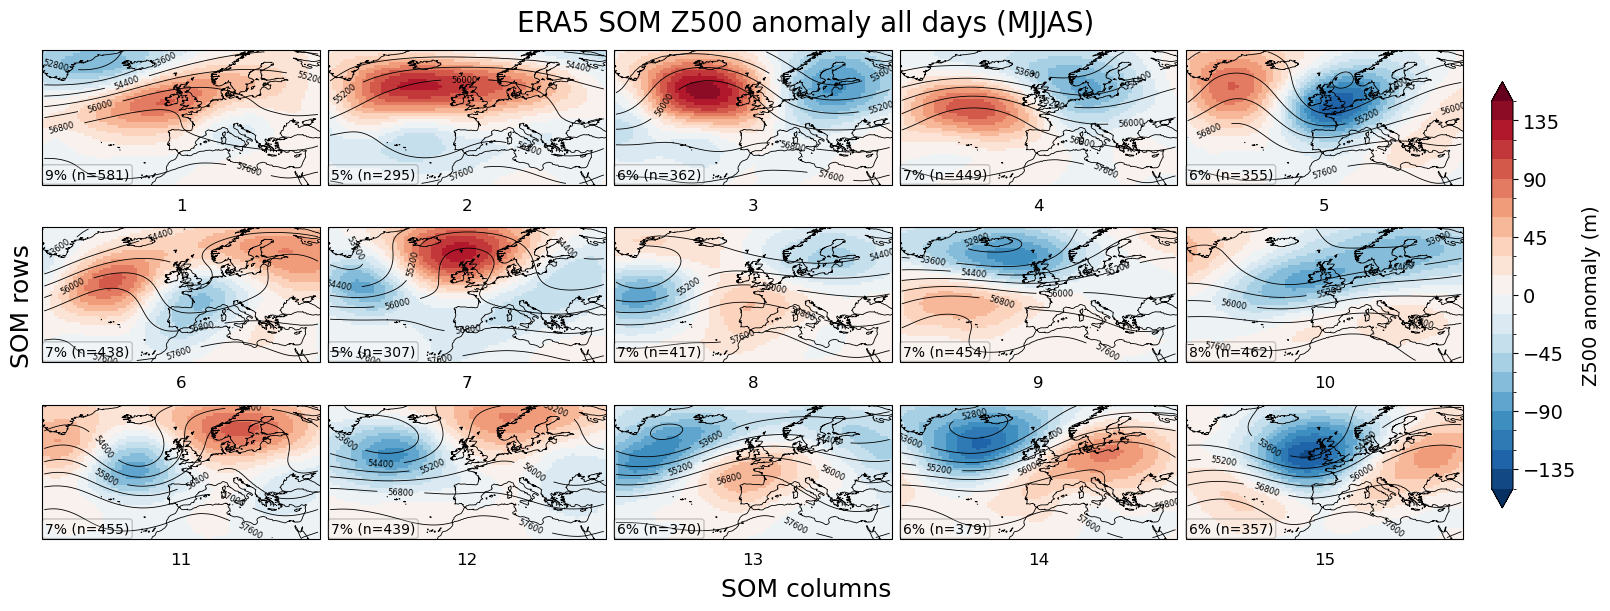

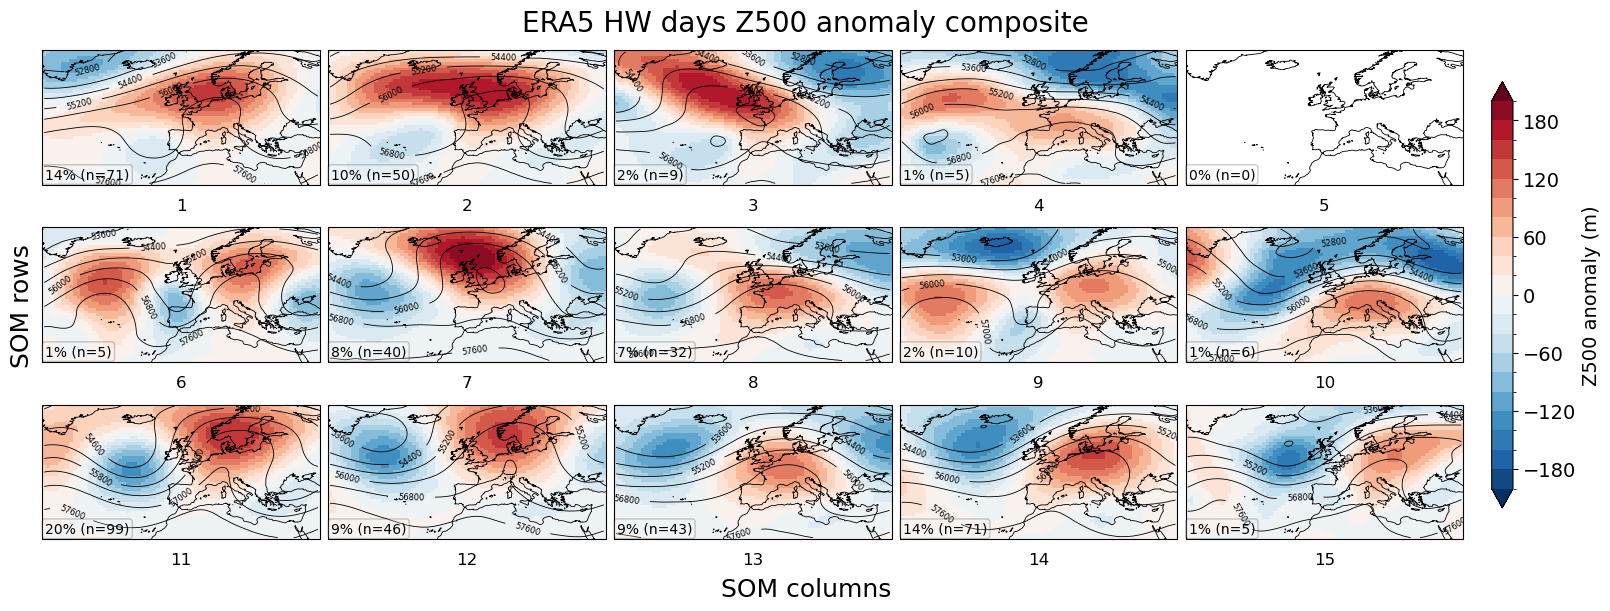

In [6]:
"""
01_era5_som_composites.py

Corresponds to original notebook sections "ERA5 All summer season days SOM"
and "ERA5 HW composites" (Fig. 7a / 7b in the revised manuscript).

UPDATE (Reviewer 3, comment 10): added a small number of contour lines
for the FULL Z500 field (not just the anomaly already shown via
shading), composited over the same days assigned to each SOM node.
This required loading the full (non-anomaly) daily Z500 field and
compositing it per node using the SAME bmu_row/bmu_col assignments
already computed for the anomaly-based SOM.

NOTE ON CLEANUP: the original notebook contained the all-summer-day SOM
plot TWICE, back to back, with byte-for-byte identical code and an
identical output filename -- a genuine duplicate, not two different
diagnostics. Only one copy is retained here.

IMPORTANT -- please verify before running: the full-field file's
variable/coordinate names are ASSUMED to follow the same convention
already used elsewhere in this project for other ERA5 files (e.g.
09_soil_moisture_coupling_diagnostic.py), i.e. "valid_time" -> "time",
"longitude" -> "lon", "latitude" -> "lat". This has NOT been verified
against the actual file, since it isn't accessible from this
environment. If the rename step below errors or is a no-op, check the
file's actual coordinate names with `ds_full.coords` and adjust.

Requires: 00_setup_and_functions.py (import * or run first)
"""

from importlib import import_module
setup = import_module("00_setup_and_functions")
globals().update(vars(setup))

# ================================================================
# ================================================================
# Load the anomaly SOM FIRST, so we can derive the full-field crop
# domain directly from its own lon/lat coordinates -- this guarantees
# the full field is cropped to EXACTLY the same domain as the anomaly
# patterns, regardless of whatever min_lon/max_lon/min_lat/max_lat
# might already exist in the global namespace from an unrelated
# earlier script run in the same session (e.g. the much smaller
# Western-Europe HW-detection domain used elsewhere in this project).
# ================================================================
ds = xr.open_mfdataset(
    f'{som_path}/som_ERA5_{VAR}_1975_{yend}_{som_grid_rows}_{som_grid_cols}_'
    f'iterations_{iterations}_learning_rate_{learning_rate}_sigma_{sigma}.nc'
)

FULL_FIELD_MIN_LON = float(ds.lon.min())
FULL_FIELD_MAX_LON = float(ds.lon.max())
FULL_FIELD_MIN_LAT = float(ds.lat.min())
FULL_FIELD_MAX_LAT = float(ds.lat.max())
print(f"Cropping full field to the anomaly SOM's own domain: "
      f"lon [{FULL_FIELD_MIN_LON}, {FULL_FIELD_MAX_LON}], "
      f"lat [{FULL_FIELD_MIN_LAT}, {FULL_FIELD_MAX_LAT}]")

# ================================================================
# Load and preprocess the FULL (non-anomaly) daily Z500 field, used
# to composite the contour overlay in both panels below.
# ================================================================
FULL_FIELD_FILE = f"/data/cmcc/ls21622/ERA5/{VAR}/postprocessed/ERA5_{VAR}_day_1975-2024_AMJJASO.nc"

ds_full = xr.open_dataset(FULL_FIELD_FILE)
if "valid_time" in ds_full.coords or "longitude" in ds_full.coords:
    ds_full = ds_full.rename({"valid_time": "time", "longitude": "lon", "latitude": "lat"})
ds_full = ds_full.sortby("lat")
if ds_full.lon.min() >= 0:
    ds_full = shift_lon(ds_full)
ds_full = crop_dom(ds_full, FULL_FIELD_MIN_LON, FULL_FIELD_MAX_LON,
                   FULL_FIELD_MIN_LAT, FULL_FIELD_MAX_LAT, lon_name="lon", lat_name="lat")
ds_full["time"] = pd.to_datetime(ds_full.time.astype("datetime64[ns]")).normalize()
ds_full = ds_full.sel(time=ds_full.time.dt.month.isin([5, 6, 7, 8, 9]))
ds_full = ds_full.sel(time=ds_full.time.dt.year.isin(range(1975, yend + 1)))

# NOTE: adjust "zg" below if the full-field file's data variable is
# named differently (e.g. "z" or "Z500").
FULL_FIELD_VARNAME = "zg" if "zg" in ds_full.data_vars else list(ds_full.data_vars)[0]
full_field_da = ds_full[FULL_FIELD_VARNAME]


def composite_full_field_by_node(bmu_row, bmu_col, bmu_time, n_rows, n_cols):
    """
    For each SOM node, composite the FULL (non-anomaly) Z500 field over
    the same days assigned to that node (matched by date to
    full_field_da), returning an (n_rows, n_cols, lat, lon) array.
    """
    bmu_time = pd.to_datetime(np.asarray(bmu_time)).normalize()
    node_idx = bmu_row * n_cols + bmu_col

    composites = np.full((n_rows * n_cols, full_field_da.lat.size, full_field_da.lon.size), np.nan)
    for k in range(n_rows * n_cols):
        dates_k = bmu_time[node_idx == k]
        if len(dates_k) == 0:
            continue
        field_k = full_field_da.sel(time=full_field_da.time.isin(dates_k))
        composites[k] = field_k.mean(dim="time", skipna=True).values

    return composites.reshape(n_rows, n_cols, full_field_da.lat.size, full_field_da.lon.size)


# ================================================================
# ERA5 all-summer-day master SOM (Fig. 7a)
# (already loaded above, to derive the full-field crop domain)
# ================================================================
full_composite_all = composite_full_field_by_node(
    ds["bmu_row"].values, ds["bmu_col"].values, ds["time"].values,
    som_grid_rows, som_grid_cols
)

if VAR == 'tos':
    levels = np.linspace(-2, 2, 21)
else:
    levels = np.linspace(-150, 150, 21)
cmap = sns.color_palette("RdBu_r", len(levels) - 1, as_cmap=True)
norm = mcolors.BoundaryNorm(levels, cmap.N, clip=False, extend='both')

fig, axs = plt.subplots(
    som_grid_rows, som_grid_cols, figsize=(16, 6),
    constrained_layout=True, subplot_kw={"projection": ccrs.PlateCarree()},
)

ntime = ds.dims["time"]
for i in range(som_grid_rows):
    for j in range(som_grid_cols):
        data = ds["patterns"].isel(som_row=i, som_col=j)
        im = axs[i, j].pcolormesh(data.lon, data.lat, data, cmap=cmap, norm=norm,
                                   shading="auto", zorder=1)

        # NEW: small number of contour lines for the full Z500 field
        full_field_node = full_composite_all[i, j]
        cs = axs[i, j].contour(full_field_da.lon, full_field_da.lat, full_field_node,
                               levels=6, colors="black", linewidths=0.6, zorder=2)
        axs[i, j].clabel(cs, inline=True, fontsize=6, fmt="%.0f")

        freq_era5 = ds["hit_counts"].isel(som_row=i, som_col=j).values / ntime * 100
        n_hits_era5 = ds["hit_counts"].isel(som_row=i, som_col=j).values

        title_text = f"{freq_era5:.0f}% (n={n_hits_era5:.0f})"
        axs[i, j].text(0.01, 0.13, title_text, transform=axs[i, j].transAxes,
                       fontsize=10, va='top', ha='left',
                       bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.2))

        node_num = node_number(i, j)
        axs[i, j].set_xlabel(f'{node_num}', fontsize=12)
        axs[i, j].xaxis.set_label_coords(0.5, -0.1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].add_feature(cfeature.COASTLINE.with_scale("50m"),
                              edgecolor="black", linewidth=0.6, zorder=3)
        if VAR == 'tos':
            axs[i, j].add_feature(cfeature.LAND, facecolor='darkgray', zorder=2)

cbar = fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.015, pad=0.02)
cbar.ax.tick_params(labelsize=14)

plt.suptitle(f"ERA5 SOM {VAR_TIT} anomaly all days (MJJAS)", fontsize=20)
if VAR == 'zg':
    cbar.set_label(f"{VAR_TIT} anomaly (m)", fontsize=14)
else:
    cbar.set_label(f"{VAR_TIT} anomaly (\u00b0C)", fontsize=14)
fig.supylabel('SOM rows', fontsize=18)
fig.supxlabel('SOM columns', fontsize=18)

plt.savefig(f'01_ERA5_SOM_{VAR}_1975_{yend}_{som_grid_rows}_{som_grid_cols}_iterations_{iterations}_learning_rate_{learning_rate}_sigma_{sigma}.png', dpi=300)


# ================================================================
# ERA5 HW-day composite (Fig. 7b)
# ================================================================
ds_hw = xr.open_mfdataset(
    f'{som_path}/som_projected_HW_days_ERA5_{VAR}_1975_{yend}_{som_grid_rows}_{som_grid_cols}_'
    f'iterations_{iterations}_learning_rate_{learning_rate}_sigma_{sigma}.nc'
)

full_composite_hw = composite_full_field_by_node(
    ds_hw["bmu_row"].values, ds_hw["bmu_col"].values, ds_hw["time"].values,
    som_grid_rows, som_grid_cols
)

if VAR == 'tos':
    levels = np.linspace(-2, 2, 21)
else:
    levels = np.linspace(-200, 200, 21)
cmap = sns.color_palette("RdBu_r", len(levels) - 1, as_cmap=True)
norm = mcolors.BoundaryNorm(levels, cmap.N, clip=False, extend='both')

fig, axs = plt.subplots(
    som_grid_rows, som_grid_cols, figsize=(16, 6),
    constrained_layout=True, subplot_kw={"projection": ccrs.PlateCarree()},
)

ntime = ds_hw.dims["time"]
for i in range(som_grid_rows):
    for j in range(som_grid_cols):
        data = ds_hw["composite"].isel(som_row=i, som_col=j)
        im = axs[i, j].pcolormesh(data.lon, data.lat, data, cmap=cmap, norm=norm,
                                   shading="auto", zorder=1)

        # NEW: small number of contour lines for the full Z500 field,
        # composited over the same HW days assigned to this node
        full_field_node = full_composite_hw[i, j]
        if not np.all(np.isnan(full_field_node)):
            cs = axs[i, j].contour(full_field_da.lon, full_field_da.lat, full_field_node,
                                   levels=6, colors="black", linewidths=0.6, zorder=2)
            axs[i, j].clabel(cs, inline=True, fontsize=6, fmt="%.0f")

        freq_era5 = ds_hw["hit_counts"].isel(som_row=i, som_col=j).values / ntime * 100
        n_hits_era5 = ds_hw["hit_counts"].isel(som_row=i, som_col=j).values

        title_text = f"{freq_era5:.0f}% (n={n_hits_era5:.0f})"
        axs[i, j].text(0.01, 0.13, title_text, transform=axs[i, j].transAxes,
                       fontsize=10, va='top', ha='left',
                       bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.2))

        node_num = node_number(i, j)
        axs[i, j].set_xlabel(f'{node_num}', fontsize=12)
        axs[i, j].xaxis.set_label_coords(0.5, -0.1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].add_feature(cfeature.COASTLINE.with_scale("50m"),
                              edgecolor="black", linewidth=0.6, zorder=3)
        if VAR == 'tos':
            axs[i, j].add_feature(cfeature.LAND, facecolor='darkgray', zorder=2)

cbar = fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.015, pad=0.02)
cbar.ax.tick_params(labelsize=14)

plt.suptitle(f"ERA5 HW days {VAR_TIT} anomaly composite", fontsize=20)
if VAR == 'zg':
    cbar.set_label(f"{VAR_TIT} anomaly (m)", fontsize=14)
else:
    cbar.set_label(f"{VAR_TIT} anomaly (\u00b0C)", fontsize=14)
fig.supylabel('SOM rows', fontsize=18)
fig.supxlabel('SOM columns', fontsize=18)

plt.savefig(
    f'01b_ERA5_projected_SOM_HW_days_{VAR}_1975_{yend}_{som_grid_rows}_{som_grid_cols}_'
    f'iterations_{iterations}_learning_rate_{learning_rate}_sigma_{sigma}.png', dpi=300)

In [3]:
min_lon=-50
max_lon=40
min_lat=25 #28
max_lat=70